# Hyperliquid Trader Performance Analysis using Bitcoin Market Sentiment

## Problem Statement

Financial markets are heavily influenced by investor psychology, and market sentiment often plays a significant role in trading behavior. The Bitcoin Fear & Greed Index provides a daily measure of market sentiment, while Hyperliquid trading data captures detailed information about traders' executed positions and realized profits.

The objective of this project is to investigate whether trader performance changes under different market sentiment conditions. By combining historical Hyperliquid trading data with the Bitcoin Fear & Greed Index, this analysis aims to identify meaningful relationships between market sentiment and trading outcomes.

The project focuses on answering the following questions:

- How is trading activity distributed across different market sentiment conditions?
- Does trader profitability vary during Fear, Neutral, and Greed markets?
- Which cryptocurrencies contribute most to trading activity and profitability?
- How do different trading directions (Long vs. Short) perform?
- What insights can be derived to support more informed trading strategies?

The findings from this analysis are intended to provide data-driven insights into trader behavior and demonstrate how market sentiment can be incorporated into trading analysis.

# Project Objective

The primary objective of this project is to explore the relationship between Bitcoin market sentiment and trader performance on Hyperliquid.

By integrating historical trading data with the Bitcoin Fear & Greed Index, the analysis aims to identify patterns in profitability, trading behavior, and market participation under different sentiment conditions. The ultimate goal is to generate actionable insights that can contribute to smarter trading strategies.

# Project Approach

The project follows a structured data analysis workflow consisting of the following stages:

### 1. Data Collection
- Load the Hyperliquid historical trading dataset.
- Load the Bitcoin Fear & Greed Index dataset.

### 2. Data Cleaning and Preprocessing
- Standardize column names.
- Convert timestamps into datetime format.
- Create a common `date` column for both datasets.
- Handle missing values and duplicate records.
- Convert numerical columns to appropriate data types.

### 3. Data Integration
- Merge the trading dataset with the Bitcoin Fear & Greed Index using the trading date.
- Validate the merge results and prepare an analysis-ready dataset.

### 4. Exploratory Data Analysis (EDA)
- Analyze the distribution of market sentiment.
- Identify the most actively traded cryptocurrencies.
- Examine trading direction patterns.
- Visualize trader profitability across different sentiment conditions.
- Explore trade size and transaction fee distributions.

### 5. Statistical Analysis
- Compare trader performance under different market sentiment categories.
- Calculate average and total realized profit (PnL).
- Compute trader win rates.
- Identify top-performing assets and trader accounts.

### 6. Business Insights and Recommendations
- Summarize the key findings.
- Highlight relationships between trader behavior and market sentiment.
- Provide recommendations that can support data-driven trading strategies.

# Evaluation Criteria Alignment

This project has been developed with the following goals:

- **Correctness & Functionality:** Build a complete and accurate data analysis pipeline from data loading to final insights.
- **Code Quality:** Use modular, reusable, and well-structured Python code.
- **Problem-Solving Approach:** Follow a logical workflow including preprocessing, validation, exploration, and statistical analysis.
- **Documentation & Communication:** Clearly explain each stage of the analysis and summarize findings using concise business insights.
- **Attention to Detail:** Validate data quality, verify dataset merges, and ensure consistency before performing analysis.

In [41]:
import os
import sys

# Go to the project root
project_root = os.path.abspath("..")
sys.path.insert(0, project_root)

print(project_root)

c:\Users\impre\OneDrive\Desktop\Hyperliquid-Sentiment-Analysis


In [5]:
#LOAD AND INSPECT DATA
from src.config import *
from src.data_loader import *
from src.preprocessing import *

trade_df = load_trading_data(TRADING_DATA_PATH)
sentiment_df = load_sentiment_data(SENTIMENT_DATA_PATH)

trade_df = standardize_columns(trade_df)
sentiment_df = standardize_columns(sentiment_df)

dataset_summary(trade_df, "Trading Dataset")
check_datatypes(trade_df)

dataset_summary(sentiment_df, "Sentiment Dataset")
check_datatypes(sentiment_df)

trade_report = data_quality_report(trade_df)
sentiment_report = data_quality_report(sentiment_df)

display(trade_report)
display(sentiment_report)

Trading dataset loaded: 211224 rows, 16 columns
Sentiment dataset loaded: 2644 rows, 4 columns

Trading Dataset
Shape           : (211224, 16)
Rows            : 211224
Columns         : 16
Duplicate Rows  : 0

Missing Values
account             0
coin                0
execution_price     0
size_tokens         0
size_usd            0
side                0
timestamp_ist       0
start_position      0
direction           0
closed_pnl          0
transaction_hash    0
order_id            0
crossed             0
fee                 0
trade_id            0
timestamp           0
dtype: int64

Data Types
account                 str
coin                    str
execution_price     float64
size_tokens         float64
size_usd            float64
side                    str
timestamp_ist           str
start_position      float64
direction               str
closed_pnl          float64
transaction_hash        str
order_id              int64
crossed                bool
fee                 float64
trade_

,Column,Data Type,Missing Values,Missing %,Unique Values
0,account,str,0,0.0,32
1,coin,str,0,0.0,246
2,execution_price,float64,0,0.0,60162
3,size_tokens,float64,0,0.0,59304
4,size_usd,float64,0,0.0,118493
5,side,str,0,0.0,2
6,timestamp_ist,str,0,0.0,27977
7,start_position,float64,0,0.0,196923
8,direction,str,0,0.0,12
9,closed_pnl,float64,0,0.0,90720


,Column,Data Type,Missing Values,Missing %,Unique Values
0,timestamp,int64,0,0.0,2644
1,value,int64,0,0.0,90
2,classification,str,0,0.0,5
3,date,str,0,0.0,2644


In [7]:
#Data Cleaning
trade_df = convert_timestamp(trade_df, "timestamp", "ms")
sentiment_df = convert_timestamp(sentiment_df, "timestamp", "s")

trade_df = add_date_column(trade_df, "timestamp")
sentiment_df = add_date_column(sentiment_df, "timestamp")

numeric_columns = [
    "execution_price",
    "size_tokens",
    "size_usd",
    "start_position",
    "closed_pnl",
    "fee"
]

trade_df = convert_numeric(trade_df, numeric_columns)

trade_df = remove_duplicates(trade_df)
sentiment_df = remove_duplicates(sentiment_df)

trade_df.info()
sentiment_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   account           211224 non-null  str           
 1   coin              211224 non-null  str           
 2   execution_price   211224 non-null  float64       
 3   size_tokens       211224 non-null  float64       
 4   size_usd          211224 non-null  float64       
 5   side              211224 non-null  str           
 6   timestamp_ist     211224 non-null  str           
 7   start_position    211224 non-null  float64       
 8   direction         211224 non-null  str           
 9   closed_pnl        211224 non-null  float64       
 10  transaction_hash  211224 non-null  str           
 11  order_id          211224 non-null  int64         
 12  crossed           211224 non-null  bool          
 13  fee               211224 non-null  float64       
 14  trade_id       

In [8]:
#Validation & Save
print("Trading Dataset")
display(trade_df.head())

print("Sentiment Dataset")
display(sentiment_df.head())

print(f"Trading Duplicates : {trade_df.duplicated().sum()}")
print(f"Sentiment Duplicates : {sentiment_df.duplicated().sum()}")

trade_df.to_csv("../data/processed/trades_clean.csv", index=False)
sentiment_df.to_csv("../data/processed/sentiment_clean.csv", index=False)

print("Clean datasets saved successfully.")

Trading Dataset


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27


Sentiment Dataset


,timestamp,value,classification,date
0,2018-02-01 05:30:00,30,Fear,2018-02-01
1,2018-02-02 05:30:00,15,Extreme Fear,2018-02-02
2,2018-02-03 05:30:00,40,Fear,2018-02-03
3,2018-02-04 05:30:00,24,Extreme Fear,2018-02-04
4,2018-02-05 05:30:00,11,Extreme Fear,2018-02-05


Trading Duplicates : 0
Sentiment Duplicates : 0
Clean datasets saved successfully.


## Dataset Merge

To analyze the relationship between trader performance and Bitcoin market sentiment, the trading dataset was merged with the Fear & Greed Index using the `date` column.

Before merging, the following validations were performed:

- Verified the date ranges of both datasets.
- Ensured there were no duplicate dates in the sentiment dataset.
- Used a left join to preserve all trading records.

In [9]:
from src.merge_data import *

check_date_range(trade_df, "Trading Dataset")
check_date_range(sentiment_df, "Sentiment Dataset")


Trading Dataset
---------------
Start Date : 2023-03-28
End Date   : 2025-06-15

Sentiment Dataset
-----------------
Start Date : 2018-02-01
End Date   : 2025-05-02


In [10]:
#Merge Datasets
merged_df = merge_datasets(
    trade_df,
    sentiment_df
)

display(merged_df.head())

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,Greed,74.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,Greed,74.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,Greed,74.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,Greed,74.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,Greed,74.0


In [31]:
analysis_df = merged_df.dropna(subset=["classification"]).copy()

print("Merged Dataset Shape :", merged_df.shape)
print("Analysis Dataset Shape :", analysis_df.shape)

Merged Dataset Shape : (211224, 19)
Analysis Dataset Shape : (184263, 19)


### Observation

The trading dataset extends until **2025-06-15**, whereas the provided Fear & Greed dataset ends on **2025-05-02**.

As a result, trades executed after the last available sentiment date could not be assigned a market sentiment.

These records were excluded from sentiment-based analyses to ensure accurate comparisons.

In [34]:
validation = pd.DataFrame({
    "Dataset": ["Trading", "Sentiment", "Merged", "Analysis"],
    "Rows": [
        len(trade_df),
        len(sentiment_df),
        len(merged_df),
        len(analysis_df)
    ],
    "Columns": [
        trade_df.shape[1],
        sentiment_df.shape[1],
        merged_df.shape[1],
        analysis_df.shape[1]
    ]
})

display(validation)
print("Missing Values in Analysis Dataset")
print(analysis_df[["classification", "value"]].isnull().sum())

,Dataset,Rows,Columns
0,Trading,211224,17
1,Sentiment,2644,4
2,Merged,211224,19
3,Analysis,184263,19


Missing Values in Analysis Dataset
classification    0
value             0
dtype: int64


In [35]:
merged_df.to_csv("../data/processed/merged_dataset.csv", index=False)

analysis_df.to_csv("../data/processed/analysis_dataset.csv", index=False)

print("Datasets saved successfully.")

Datasets saved successfully.


# Exploratory Data Analysis

The objective of this section is to understand trader behavior and market characteristics before performing statistical analysis.

The following questions are explored:

- How is market sentiment distributed?
- Which coins are traded most frequently?
- How are trades distributed across Long and Short directions?

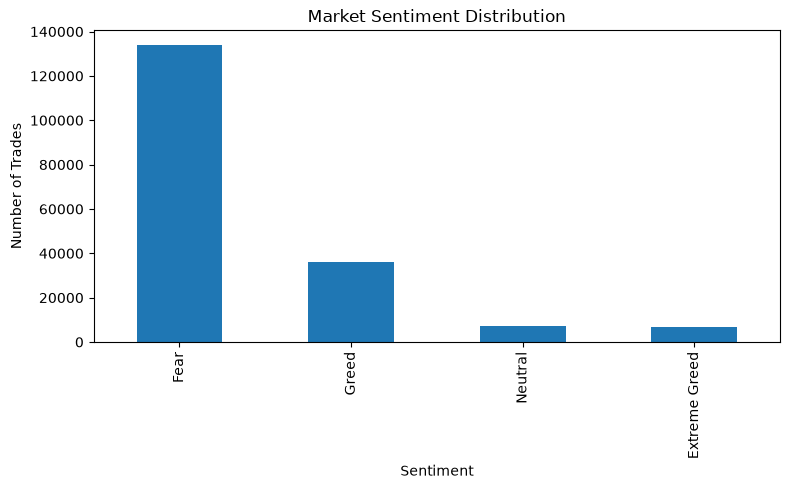

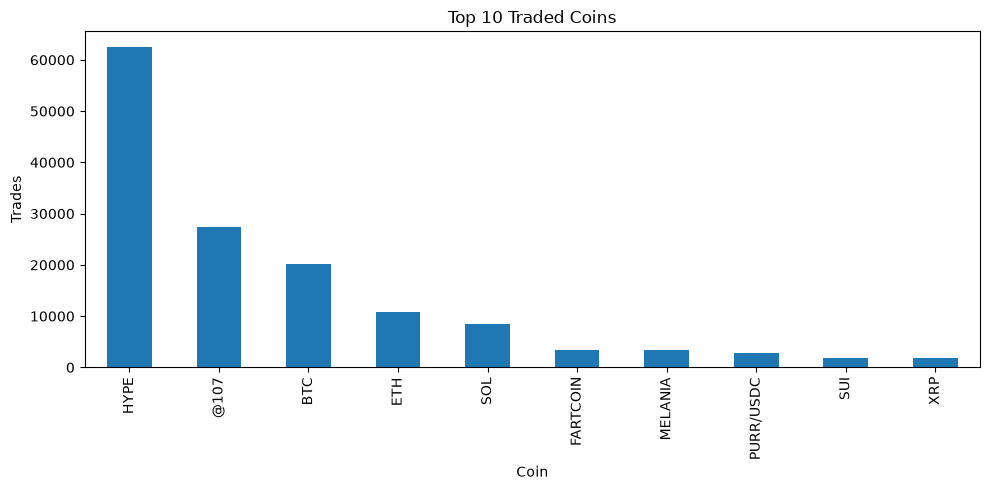

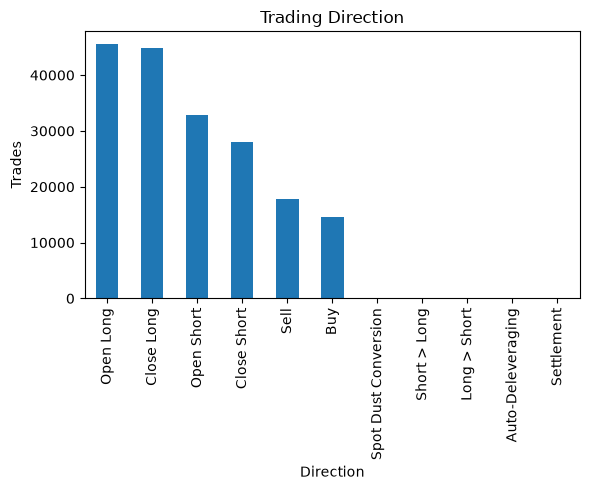

In [ ]:
from src.eda import *

import importlib
import src.eda as eda

importlib.reload(eda)

from src.eda import *

sentiment_distribution(analysis_df)

top_traded_coins(analysis_df)

direction_distribution(analysis_df)

## Trader Performance

This section evaluates how profitability changes under different market conditions.

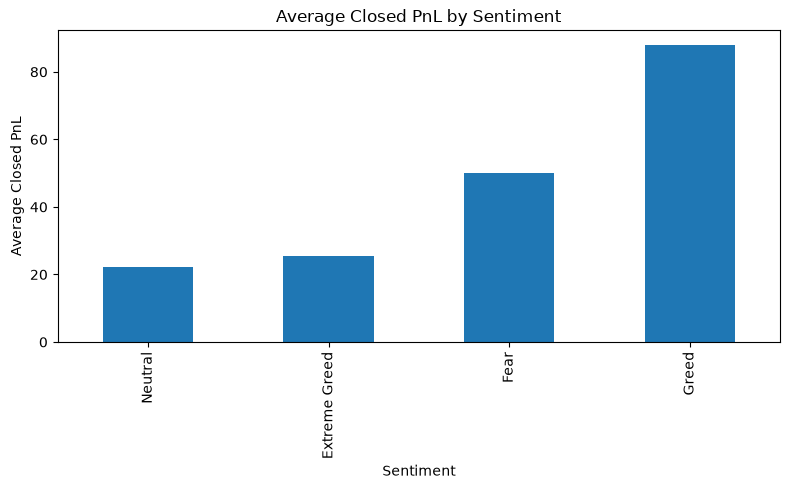

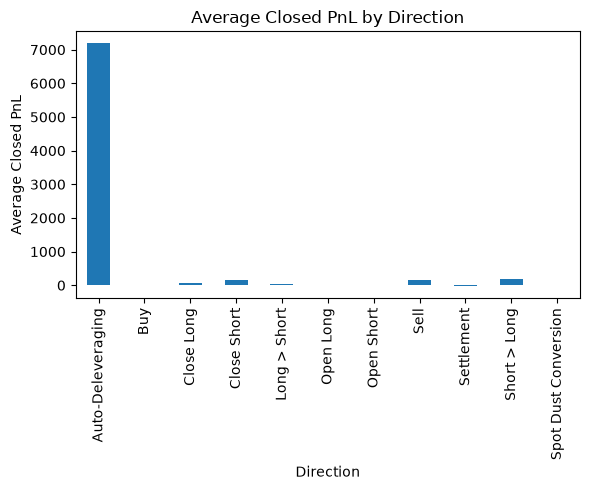

In [ ]:
pnl_by_sentiment(analysis_df)

pnl_by_direction(analysis_df)

## Trade Characteristics

This section examines trade sizes and transaction fees.

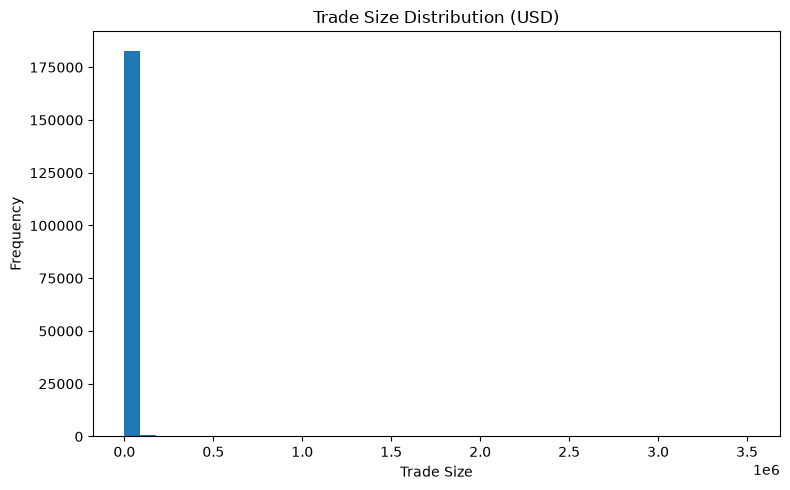

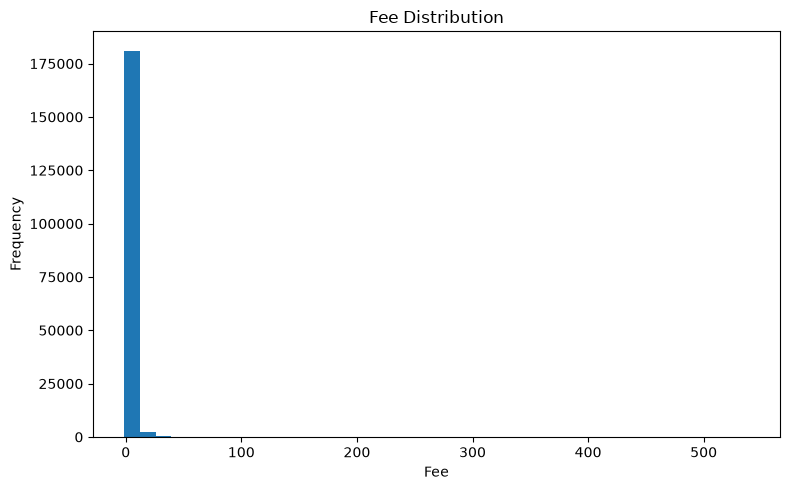

In [38]:
trade_size_distribution(analysis_df)

fee_distribution(analysis_df)

## Key Insights from Exploratory Data Analysis

The exploratory analysis reveals several important patterns:

- Trading activity is concentrated during **Fear** market conditions.
- A small number of cryptocurrencies account for most trading activity, with **HYPE** being the most frequently traded asset.
- Long-position trades occur more frequently than short-position trades.
- Average trader profitability differs across market sentiment categories, with the highest average closed PnL observed during **Greed** conditions in this dataset.
- Both trade sizes and trading fees exhibit highly right-skewed distributions, indicating that most trades are relatively small while a few large trades contribute disproportionately to the overall volume.

## Outlier Analysis

Before performing statistical analysis, it is useful to examine the presence of outliers in key numerical variables such as trade size, trading fee, and closed profit/loss.

Boxplots provide a clear visualization of extreme observations that may influence summary statistics.

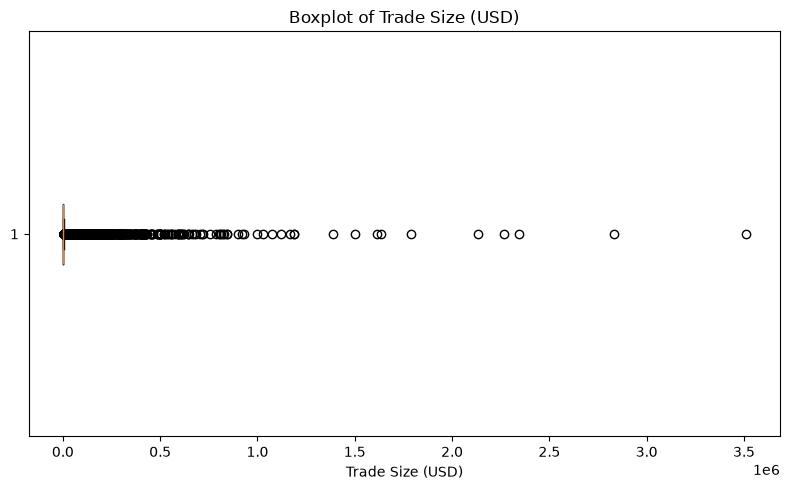

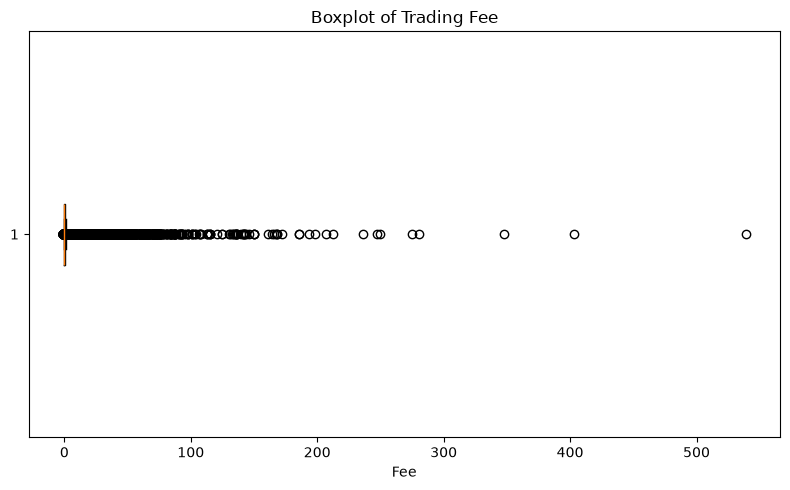

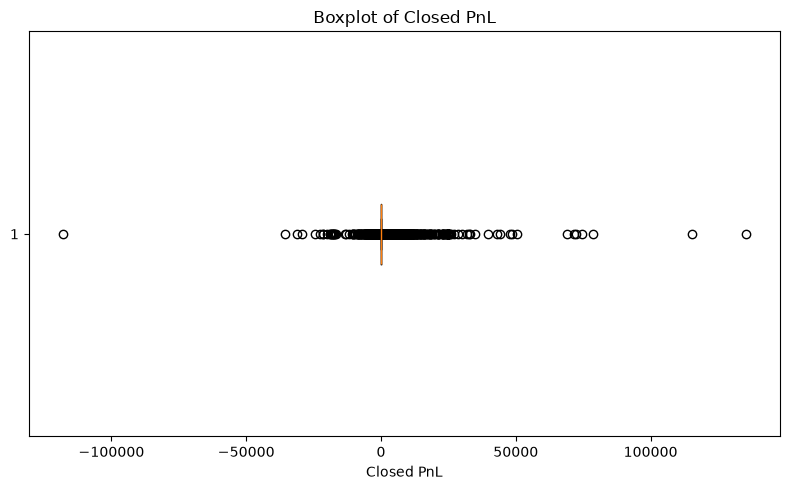

In [45]:
boxplot_trade_size(analysis_df)

boxplot_fee(analysis_df)

boxplot_closed_pnl(analysis_df)

In [46]:
analysis_df[
    [
        "execution_price",
        "size_usd",
        "closed_pnl",
        "fee"
    ]
].describe().round(2)

,execution_price,size_usd,closed_pnl,fee
count,184263.00,184263.00,184263.00,184263.00
mean,9624.18,4780.73,55.49,1.00
std,27106.27,26904.28,937.86,5.15
min,0.00,0.00,-117990.10,-1.18
25%,5.02,187.53,0.00,0.02
50%,17.77,592.74,0.00,0.09
75%,28.92,2032.70,6.60,0.39
max,109004.00,3509752.98,135329.09,539.02


### Observation

The boxplots indicate the presence of several extreme values in trade size, trading fee, and closed profit/loss. While most observations are concentrated within a relatively narrow range, a small number of trades have substantially larger values. These outliers may influence measures such as the mean and should be considered when interpreting the results of the subsequent statistical analysis.

In [48]:
from src.analysis import *

## Performance by Market Sentiment

The table below summarizes trader performance across different market sentiment conditions.

In [49]:
sentiment_stats = sentiment_statistics(analysis_df)

sentiment_stats

,Trades,Average_PnL,Median_PnL,Total_PnL,Average_Trade_Size,Average_Fee
classification,,,,,,
Greed,36289,87.89,0.0,3189616.54,3182.88,0.67
Fear,133871,50.05,0.0,6699925.19,5259.98,1.08
Extreme Greed,6962,25.42,0.0,176965.49,5660.27,0.98
Neutral,7141,22.23,0.0,158742.38,3058.85,1.22


### Observation

The win rate represents the percentage of trades that closed with a positive profit under each market sentiment category.

In [50]:
win_rate = win_rate_by_sentiment(analysis_df)

win_rate

,classification,Win Rate (%)
0,Extreme Greed,49.01
1,Fear,41.51
2,Greed,44.65
3,Neutral,31.72


In [51]:
direction_stats = direction_statistics(analysis_df)

direction_stats

,Trades,Average_PnL,Total_PnL
direction,,,
Auto-Deleveraging,8,7184.81,57478.46
Short > Long,65,187.57,12191.96
Sell,17890,161.29,2885395.45
Close Short,28091,148.06,4159132.52
Close Long,44935,69.19,3109116.86
Long > Short,54,36.36,1963.56
Buy,14657,0.00,0.00
Open Short,32861,0.00,0.00
Open Long,45564,0.00,0.00


In [52]:
coin_stats = coin_statistics(analysis_df)

coin_stats

,Trades,Total_PnL,Average_PnL
coin,,,
@107,27385,2776897.53,101.40
HYPE,62446,1911331.06,30.61
ETH,10862,1431097.42,131.75
SOL,8523,1371096.31,160.87
BTC,20135,659311.31,32.74
MELANIA,3322,316800.57,95.36
ENA,990,217329.50,219.52
SUI,1847,198683.22,107.57
ZRO,1239,183777.78,148.33


In [53]:
top10 = top_traders(analysis_df)

top10

,Trades,Total_PnL,Average_PnL
account,,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14410,2040922.43,141.63
0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1600229.82,419.13
0xbaaaf6571ab7d571043ff1e313a9609a10637864,21190,940157.21,44.37
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,36534,811182.98,22.20
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,4134,674404.00,163.14
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,1134,425815.20,375.50
0x430f09841d65beb3f27765503d0f850b8bce7713,1051,416541.87,396.33
0x513b8629fe877bb581bf244e326a047b249c4ff1,6000,403501.65,67.25
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,1358,393683.01,289.90


## Statistical analysis

The statistical analysis complements the exploratory visualizations by quantifying trader performance across different market conditions.

Key findings include:

- Market sentiment is associated with differences in trader profitability and win rate.
- Trading performance varies across different transaction directions.
- A relatively small number of cryptocurrencies contribute a large share of the overall profit.
- Trader performance is unevenly distributed, with a small group of accounts generating a significant portion of the total realized profit.

These results provide quantitative evidence that market sentiment and trading behavior are related, supporting further investigation into sentiment-aware trading strategies.

# Final Business Insights

Based on the exploratory and statistical analyses, the following key insights were identified:

1. **Trading activity is concentrated during Fear market conditions**, indicating that traders remain highly active even when market sentiment is negative.

2. **Profitability varies across different market sentiment categories.** In this dataset, trades executed during **Greed** conditions show the highest average realized profit, while Neutral and Extreme Greed exhibit comparatively lower average profits.

3. **Long positions dominate trading activity**, with Open Long and Close Long transactions occurring more frequently than short positions.

4. **Trading volume is concentrated in a small number of cryptocurrencies.** HYPE is the most actively traded asset, followed by @107 and BTC.

5. **Trade size and transaction fees are highly skewed**, suggesting that a relatively small number of large trades contribute significantly to the overall trading volume and costs.

6. **Trader performance is unevenly distributed**, with a small number of accounts contributing a substantial share of the total realized profit.

# Recommendations

Based on the findings from this analysis, the following recommendations can help improve trading strategies:

- Incorporate Bitcoin Fear & Greed sentiment as an additional indicator when evaluating trading opportunities.
- Monitor market sentiment alongside technical indicators rather than relying on sentiment alone.
- Analyze the trading behavior of consistently profitable accounts to identify effective trading patterns.
- Apply appropriate risk management during periods of extreme market sentiment, as profitability varies across sentiment categories.
- Focus further analysis on frequently traded assets such as HYPE and BTC, as they account for a significant proportion of trading activity.
- Extend the analysis by including additional market indicators such as Bitcoin price, trading volume, and volatility to build more comprehensive predictive models.

# Conclusion

This project explored the relationship between Bitcoin market sentiment and trader performance by combining historical trading data with the Bitcoin Fear & Greed Index.

The analysis involved data cleaning, preprocessing, dataset integration, exploratory analysis, and statistical summaries. The results indicate that trader behavior and profitability differ across market sentiment conditions, while trading activity is concentrated in a limited number of assets and transaction types.

Although market sentiment alone cannot explain trading performance, it provides useful contextual information that can support trading decisions when combined with other market indicators.